# Data Source
https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset

# Data Loading and Preprocessing

In [4]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define directories
data_dir = '/kaggle/input/tuberculosis-tb-chest-xray-dataset/TB_Chest_Radiography_Database'

# Image Data Generator for rescaling images
datagen = ImageDataGenerator(rescale=1.0/255)

# Load data
generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Extract features and labels
features = []
labels = []

for i in range(len(generator)):
    x, y = next(generator)
    features.extend(x)
    labels.extend(y)

features = np.array(features)
labels = np.array(labels)

print(f'Features shape: {features.shape}')
print(f'Labels shape: {labels.shape}')

Found 4200 images belonging to 2 classes.
Features shape: (4200, 224, 224, 3)
Labels shape: (4200,)


# Apply SMOTE to cater Data Imbalance

In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Reshape features for SMOTE
n_samples, height, width, channels = features.shape
features_reshaped = features.reshape(n_samples, -1)

# Apply SMOTE
smote = SMOTE()
features_resampled, labels_resampled = smote.fit_resample(features_reshaped, labels)

# Reshape features back to the original shape
features_resampled = features_resampled.reshape(-1, height, width, channels)

print(f'Resampled features shape: {features_resampled.shape}')
print(f'Resampled labels shape: {labels_resampled.shape}')

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(features_resampled, labels_resampled, test_size=0.2, random_state=42)

Resampled features shape: (7000, 224, 224, 3)
Resampled labels shape: (7000,)


# Model Definition and Training

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load the pre-trained EfficientNetB0 model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(1, activation='sigmoid')(x)

# Define the model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
  1/175 ━━━━━━━━━━━━━━━━━━━━ 4:46:32 99s/step - accuracy: 0.4688 - loss: 0.7377

I0000 00:00:1720629337.475922     184 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 137s 218ms/step - accuracy: 0.9608 - loss: 0.0990 - val_accuracy: 0.4921 - val_loss: 2.0751
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9972 - loss: 0.0093 - val_accuracy: 0.4943 - val_loss: 3.4366
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.5143 - val_loss: 2.4882
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9960 - loss: 0.0130 - val_accuracy: 0.8450 - val_loss: 0.6238
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 0.9907 - val_loss: 0.0243
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9988 - loss: 0.0043 - val_accuracy: 0.8879 - val_loss: 0.3502
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.9914 - val_loss: 0.0160
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 129ms/step - accuracy: 1.0000 - loss: 2.3961e-04 

# Evaluation

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 4.2393e-04
Validation Loss: 0.00032403302611783147
Validation Accuracy: 1.0


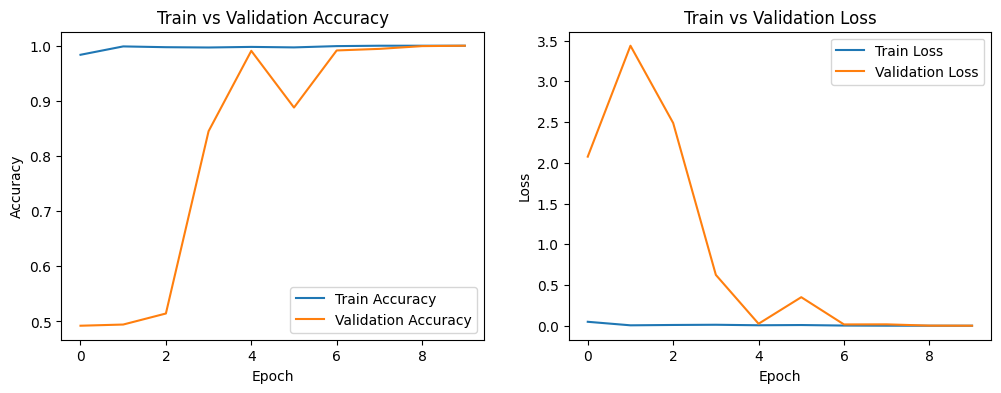

In [7]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')

plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       711
Tuberculosis       1.00      1.00      1.00       689

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400

[[711   0]
 [  0 689]]


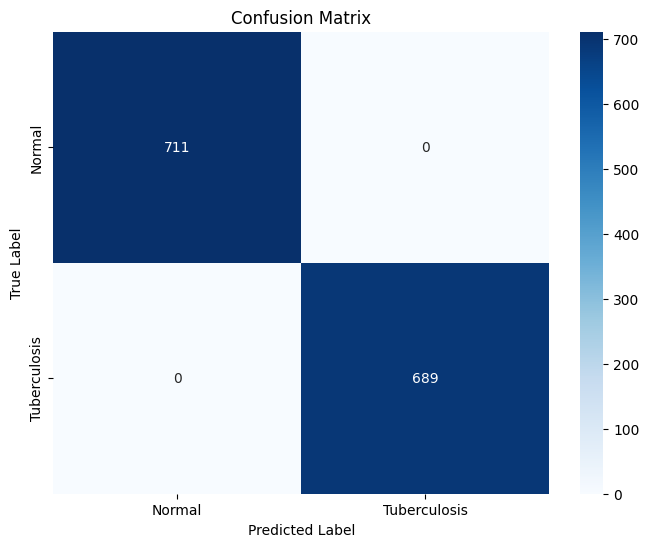

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get the predictions
predictions = model.predict(X_val)
predicted_classes = np.where(predictions > 0.5, 1, 0).flatten()

# Generate classification report
report = classification_report(y_val, predicted_classes, target_names=['Normal', 'Tuberculosis'])
print(report)

# Generate confusion matrix
conf_matrix = confusion_matrix(y_val, predicted_classes)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Tuberculosis'], yticklabels=['Normal', 'Tuberculosis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [9]:
model.save("tb_model.h5")